<a href="https://colab.research.google.com/github/pri-2711/qiskit_codes/blob/main/Qiskit_code_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Deutsch's Algorithm

In [3]:
!pip install qiskit
!pip install jupyter
!pip install sympy
!pip install matplotlib
!pip install pylatexenc
!pip install qiskit_aer
!pip install qiskit_ibm_runtime
!pip install qiskit_ibm_provider

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.0/913.0 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 115.7 MB/s eta 0:00:00
  Attempting uninstall: jupyter-server
    Found existing installation: jupyter_server 2.18.2
    Uninstalling jupyter_server-2.18.2:
      Successfully uninstalled jupyter_server-2.18.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires jupyter-server==2.18.2, but you have jupyter-server 2.20.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/16

In [4]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random

In [5]:
#Input function Preparation: We have 4 sample functions
def deutsch_algorithm(case: int):
  if case not in [1,2,3,4]:
    raise ValueError("Invalid, case should be in 1,2,3 or 4")
  f=QuantumCircuit(2) # there are 2 qubits
  if case in [2,3]:
    f.cx(0,1) #1st-control, 2nd-target
  if case in [3,4]:
    f.x(1)
  return f

*   CASE= 1: f(x) = 0 - Constant
*   CASE= 2: f(x) = x - Balanced
*   CASE= 3: f(x) = $\bar{x}$ - Balanced
*   CASE= 4: f(x) = 1 - Constant

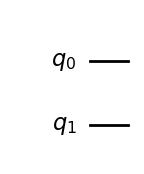

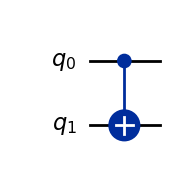

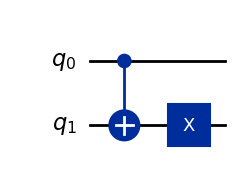

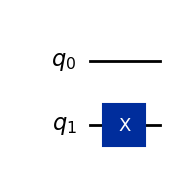

In [6]:
display(deutsch_algorithm(1).draw("mpl"))
display(deutsch_algorithm(2).draw("mpl"))
display(deutsch_algorithm(3).draw("mpl"))
display(deutsch_algorithm(4).draw("mpl"))

In [9]:
#making the circuit with ORACLE function
def compile_circuit(function: QuantumCircuit):
  n=function.num_qubits-1 #removng the ancilla/output qubit
  qc=QuantumCircuit(n+1,n)

  #circuit
  qc.x(n)
  qc.h(range(n+1))
  qc.barrier()
  #Oracle function
  qc.compose(function,inplace=True)
  qc.barrier()
  qc.h(range(n))
  qc.measure(range(n),range(n))

  return qc


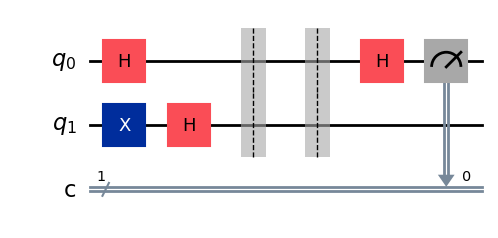

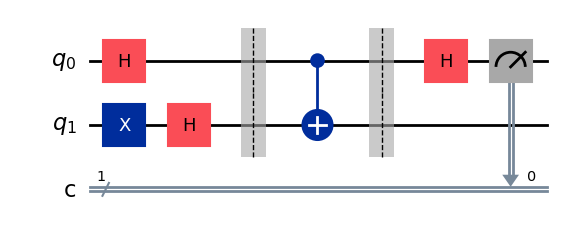

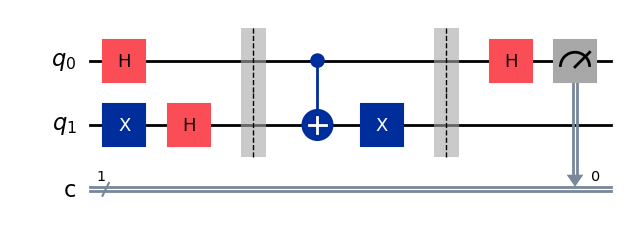

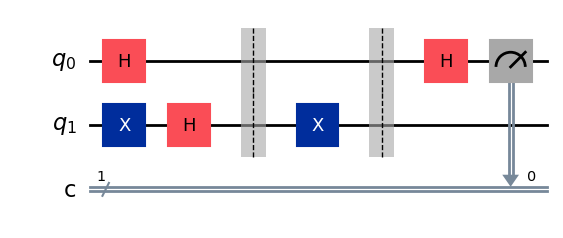

In [10]:
display(compile_circuit(deutsch_algorithm(1)).draw("mpl"))
display(compile_circuit(deutsch_algorithm(2)).draw("mpl"))
display(compile_circuit(deutsch_algorithm(3)).draw("mpl"))
display(compile_circuit(deutsch_algorithm(4)).draw("mpl"))